In [3]:
import os
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt

In [4]:
start_year = 2004
end_year = start_year
pred_file = f'../results/{start_year}-{end_year}/hdpsm_nrep10_mratio5_drug_reaction_associations.csv'

In [5]:
preds = pd.read_csv(pred_file)
preds['reaction'] = preds['reaction'].str.lower()
preds['mean'] = preds['a']/(preds['a']+preds['b'])
preds.head()

,drug,reaction,patient_sex,replicate,a,b,c,d,OR,PRR,PHI,mean
0,sufentanil,myocardial ischaemia,All,0,11,31,3,175,20.698925,15.539683,0.394542,0.261905
1,sufentanil,post procedural complication,All,0,11,31,19,159,2.969440,2.453634,0.177699,0.261905
2,sufentanil,bradycardia,All,0,5,37,9,169,2.537538,2.354497,0.110265,0.119048
3,sufentanil,drug interaction,All,0,6,36,15,163,1.811111,1.695238,0.078362,0.142857
4,sufentanil,hypotension,All,0,5,37,10,168,2.270270,2.119048,0.098026,0.119048


In [6]:
# negative controls
negative_files = [f for f in os.listdir('../data') if f.endswith(f"confounded_examples_{start_year}-{end_year}.csv")]
negative_df = None
for fn in negative_files:
    df = pd.read_csv(os.path.join('../', 'data', fn))
    if negative_df is None:
        negative_df = df
    else:
        negative_df = pd.concat([negative_df, df])

negative_df['reaction'] = negative_df['reaction'].str.lower()
negative_df['label'] = 0
negative_df.head()

,Unnamed: 0,indication,reaction,drug,PHI_conf_drug,PRR_drug_rea,conf_drug,sex,age,label
0,1,ABDOMINAL PAIN,abdominal pain,alosetron,0.009654,17.092641,NaN,NaN,NaN,0
1,32,ABNORMAL BEHAVIOUR,abnormal behaviour,atomoxetine,0.027855,16.336813,NaN,NaN,NaN,0
2,46,ABORTION INDUCED,menorrhagia,levonorgestrel,0.015636,12.010940,NaN,NaN,NaN,0
3,50,ABORTION INDUCED,abortion incomplete,misoprostol,0.238401,2457.551708,NaN,NaN,NaN,0
4,52,ABORTION INDUCED,haemorrhage,misoprostol,0.238401,17.376216,NaN,NaN,NaN,0


In [7]:
# positive controls
fn = '../data/onsides_public_warnings_and_precautions.csv'
positive_df = pd.read_csv(fn)
positive_df['pt_meddra_term'] = positive_df['pt_meddra_term'].str.lower()
positive_df.rename(columns={'pt_meddra_term': 'reaction', 'ingredients_names': 'drug'}, inplace=True)
positive_df['label'] = 1
positive_df.head()

,ingredients_rxcuis,drug,pt_meddra_id,reaction,label
0,321988,escitalopram,10012218,delirium,1
1,1364347,ponatinib,10003668,atrial tachycardia,1
2,4493,fluoxetine,10025197,lymphadenopathy,1
3,4099,"estrogens, conjugated (USP)",10016807,fluid retention,1
4,753340,sapropterin,10037211,psychomotor hyperactivity,1


In [8]:
reference = pd.concat([positive_df[['drug', 'reaction', 'label']], negative_df[['drug', 'reaction', 'label']]])
reference.tail()

,drug,reaction,label
9,atomoxetine,prescribed overdose,0
10,atomoxetine,psychomotor hyperactivity,0
11,atomoxetine,retching,0
12,atomoxetine,tic,0
13,isotretinoin,benign intracranial hypertension,0


In [9]:
pred_drugs = set(preds.drug.unique())
ref_drugs = set(reference.drug.unique())
len(pred_drugs), len(ref_drugs), len(pred_drugs&ref_drugs)

(450, 1215, 406)

In [10]:
pred_reactions = set(preds.reaction.unique())
ref_reactions = set(reference.reaction.unique())
len(pred_reactions), len(ref_reactions), len(pred_reactions&ref_reactions)

(1801, 2343, 1203)

In [11]:
merged = pd.merge(preds, reference, on=['drug', 'reaction'], how='inner')
merged.label.sum(), len(merged.label)

(59219, 200150)

0.3362592620407405
0.21589090191884422


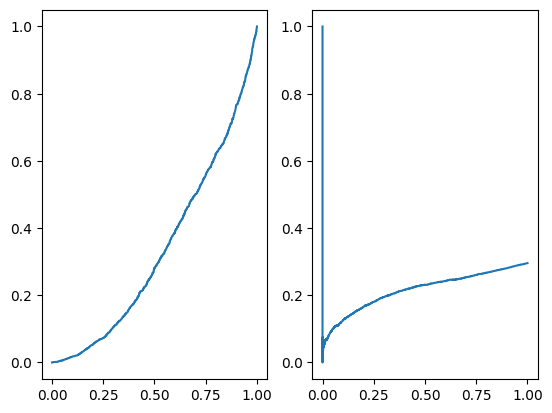

In [12]:
col = 'mean'

print(metrics.roc_auc_score(merged['label'], merged[col]))
print(metrics.average_precision_score(merged['label'], merged[col]))
fpr, tpr, thresholds = metrics.roc_curve(merged['label'], merged[col], pos_label=1)
plt.subplot(1,2,1)
plt.plot(fpr, tpr)

pr, re, th = metrics.precision_recall_curve(merged['label'], merged[col])
plt.subplot(1,2,2)
plt.plot(re, pr)


In [13]:
neg = merged[col][merged['label']==0]
pos = merged[col][merged['label']==1]
neg.mean(), pos.mean()

(0.07398177494047933, 0.0388709872596357)